#  Prepare the data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/citibike_final_cleaned.csv")

df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

print("Shape:", df.shape)

C:\Users\MY PC\AppData\Local\Temp\ipykernel_10280\1897287476.py:4: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/citibike_final_cleaned.csv")


Shape: (5238215, 24)


# Select ML features

In [2]:
features = [
    "trip_distance_km",
    "hour",
    "is_weekend",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"
]

target = "trip_duration_min"

ml_df = df[features + [target]].copy()

print("ML dataset shape:", ml_df.shape)
ml_df.head()

ML dataset shape: (5238215, 8)


,trip_distance_km,hour,is_weekend,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,trip_duration_min
0,1.399493,20,False,24.9,89,0.5,13.1,8.949867
1,4.403046,18,False,27.2,35,0.0,12.2,30.201400
2,0.990657,15,False,22.9,93,2.7,16.7,4.004267
3,0.251485,22,True,23.8,61,0.0,9.0,1.694633
4,2.008467,21,False,26.8,44,0.0,7.3,9.122933


# @ Check missing values

In [3]:
print(ml_df.isnull().sum())

trip_distance_km        16241
hour                        0
is_weekend                  0
temperature_2m              0
relative_humidity_2m        0
precipitation               0
wind_speed_10m              0
trip_duration_min           0
dtype: int64


# @ Remove missing feature rows

In [4]:
ml_df = ml_df.dropna()

print("Shape after removing missing values:", ml_df.shape)
print("Missing values:")
print(ml_df.isnull().sum())

Shape after removing missing values: (5221974, 8)
Missing values:
trip_distance_km        0
hour                    0
is_weekend              0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
trip_duration_min       0
dtype: int64


# @ Separate Features (X) and Target (y)

In [5]:
X = ml_df[features]
y = ml_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5221974, 7)
y shape: (5221974,)


# @ Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4177579, 7)
X_test : (1044395, 7)
y_train: (4177579,)
y_test : (1044395,)


# @ Train Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


# @ Make Predictions

In [9]:
y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))

Number of predictions: 1044395


# @ Evaluate the Linear Regression Model

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Linear Regression Results
-------------------------
MAE  : 5.389436964036185
MSE  : 285.98586595217347
RMSE : 16.911116638240465
R²   : 0.16178915102297708


# @ Actual vs Predicted Plot

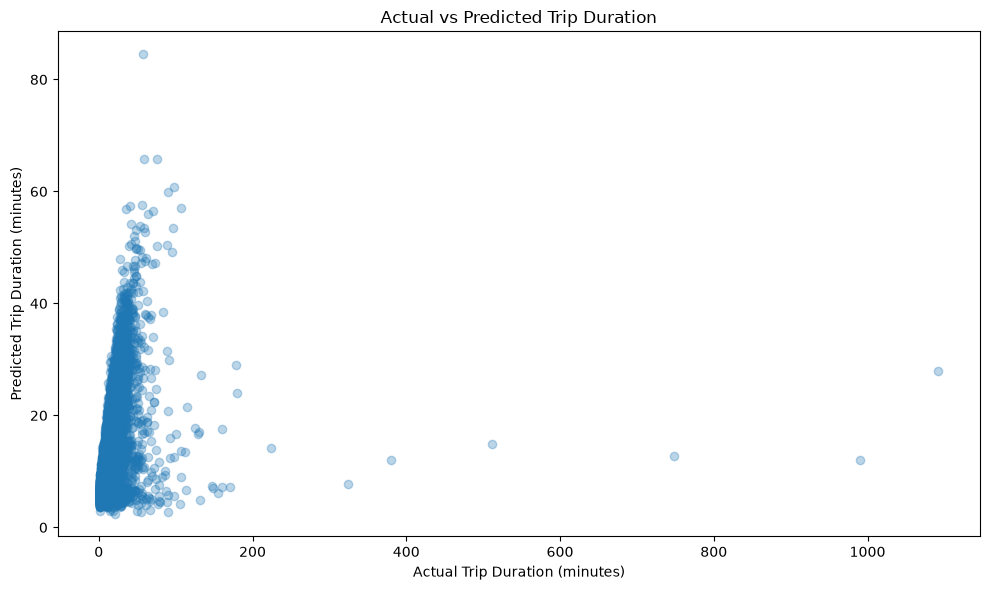

In [11]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}).sample(10000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["Actual"],
    plot_df["Predicted"],
    alpha=0.3
)

plt.xlabel("Actual Trip Duration (minutes)")
plt.ylabel("Predicted Trip Duration (minutes)")
plt.title("Actual vs Predicted Trip Duration")

plt.tight_layout()
plt.savefig("../reports/linear_regression_actual_vs_predicted.png", dpi=300)

plt.show()

# @ Residual Analysis

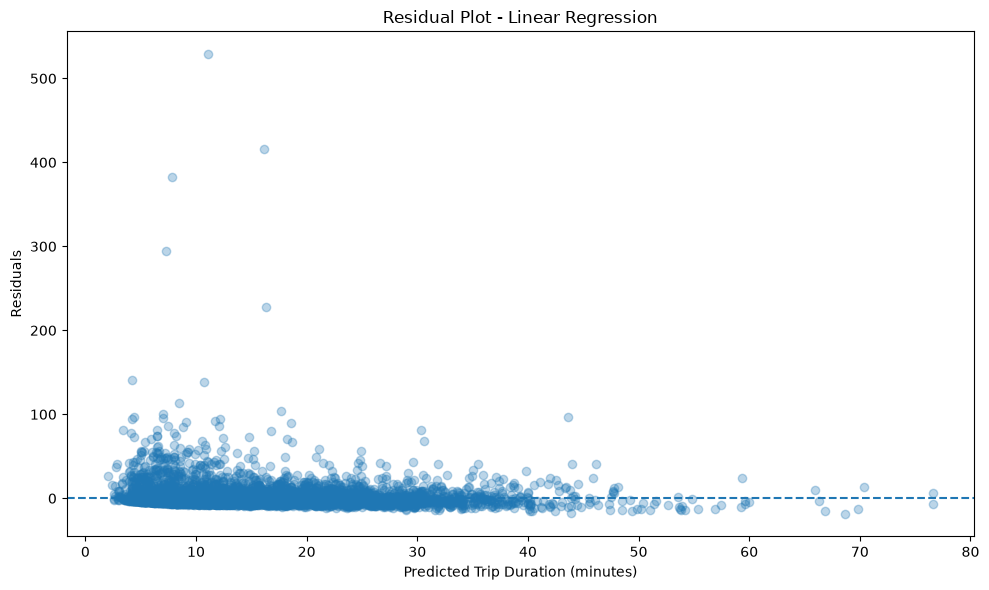

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred[:10000],
    residuals[:10000],
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Trip Duration (minutes)")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.tight_layout()
plt.savefig("../reports/linear_regression_residuals.png", dpi=300)

plt.show()


# @ Feature Coefficients

In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

print(coefficients)

                Feature  Coefficient
0      trip_distance_km     4.037992
2            is_weekend     2.155169
3        temperature_2m     0.096521
1                  hour     0.066362
4  relative_humidity_2m    -0.014216
5         precipitation    -0.032901
6        wind_speed_10m    -0.037045


In [14]:
print("\nIntercept:", model.intercept_)


Intercept: 1.9694568463357118
